In [2]:
import sys
import os
import pandas as pd

sys.path.append('c:\\Users\\andres\\Desktop\\SEPTIMO SEMESTRE\\MONITORIA\\analisis')

import connection as conn

co=conn.connect()

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



### Q1: What is the predominant biological sex and age group (life cycle) of smokers observed on campus?

In [ ]:
df=pd.read_sql("""
SELECT * FROM question_question as q
JOIN response_response as r
ON r.question_id = q.id
WHERE q.parent_question_id= 2
OR q.parent_question_id = 9
""",co)

In [27]:
df

,id,code,question_type,description,parent_question_id,subcategory_id,is_required,position,input_type,id,numeric_value,text_value,option_id,question_id,visita_id
0,3,B.2,matrix_child,Hombre,2,1,1,2.0,NUM,3949,1,None,2,3,122
1,3,B.2,matrix_child,Hombre,2,1,1,2.0,NUM,4092,3,None,4,3,123
2,4,B.1,matrix_child,Mujer,2,1,1,1.0,NUM,3950,1,None,2,4,122
3,4,B.1,matrix_child,Mujer,2,1,1,1.0,NUM,4093,1,None,2,4,123
4,33,B.4,matrix_child,Expresión mixta/no definida,2,1,1,4.0,NUM,3968,1,None,2,33,122
5,33,B.4,matrix_child,Expresión mixta/no definida,2,1,1,4.0,NUM,4111,1,None,2,33,123
6,34,B.5,matrix_child,Indeterminada,2,1,1,5.0,NUM,3969,2,None,3,34,122
7,34,B.5,matrix_child,Indeterminada,2,1,1,5.0,NUM,4112,4,None,5,34,123
8,6,C.1,matrix_child,Mestizos,5,1,1,1.0,NUM,3951,1,None,2,6,122
9,6,C.1,matrix_child,Mestizos,5,1,1,1.0,NUM,4094,3,None,4,6,123


QUESTION: What is the predominant biological sex and
          age group of smokers observed on campus?

── BIOLOGICAL SEX ──────────────────────────────────────
Observed counts:
description
Expresión mixta/no definida    2
Hombre                         4
Indeterminada                  6
Mujer                          2

Total observed: 14
Predominant category: Indeterminada (n=6)

Chi-square Goodness of Fit:
  chi2 = 3.1429
  p-value = 0.3701
  ⚠️  Result: No significant difference between categories (p >= 0.05)

Fisher's Exact Test (Hombre vs Mujer only, excluding undefined):
  Hombre: 4  |  Mujer: 2
  Odds Ratio = 4.0000
  p-value = 0.5671
  ⚠️  No significant difference between men and women (p >= 0.05)

── AGE GROUPS (LIFE CYCLE) ─────────────────────────────
Observed counts:
description
Adolescente (12-18 años)    7
Joven(14-26 años)           6
Adulto (27-59 años)         7
Adulto Mayor (> 60 años)    5

Total observed: 25
Predominant category: Adolescente (12-18 años) (n=7)

C

C:\Users\andres\AppData\Local\Temp\ipykernel_6980\2267731045.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✅ Chart saved as smokers_analysis.png


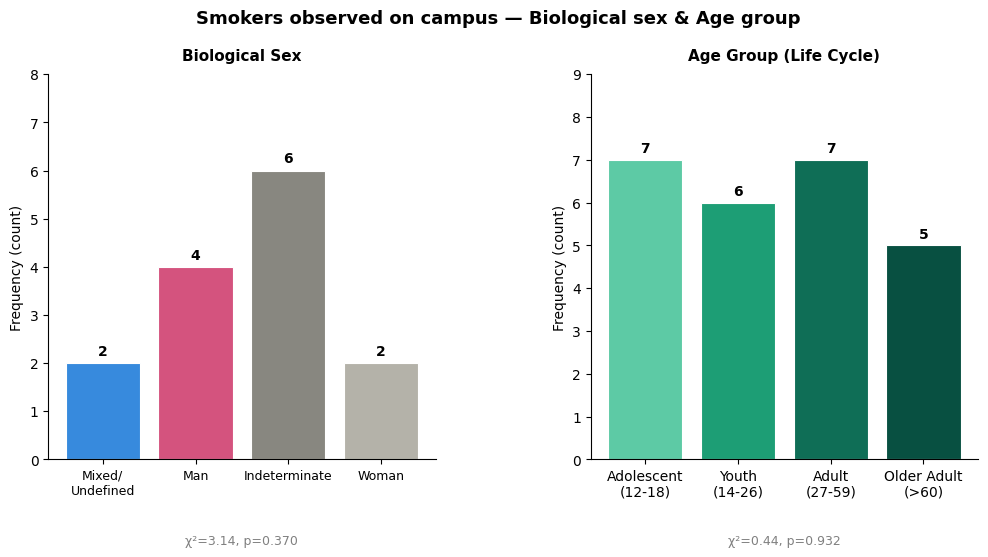

In [36]:

from scipy.stats import chisquare, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

sex_codes = ['B.1', 'B.2', 'B.4', 'B.5']
age_codes = ['D.1', 'D.2', 'D.3', 'D.4']
 
sex_df = df[df['code'].isin(sex_codes)].groupby('description')['numeric_value'].sum()
age_df = df[df['code'].isin(age_codes)].groupby('description')['numeric_value'].sum()
 
# Reorder age groups logically
age_order = ['Adolescente (12-18 años)', 'Joven(14-26 años)',
             'Adulto (27-59 años)', 'Adulto Mayor (> 60 años)']
age_df = age_df.reindex(age_order)
 
# ── 2. Chi-square Goodness of Fit ─────────────────────────────────────────────
print("=" * 60)
print("QUESTION: What is the predominant biological sex and")
print("          age group of smokers observed on campus?")
print("=" * 60)
 
# --- Biological Sex ---
print("\n── BIOLOGICAL SEX ──────────────────────────────────────")
print(f"Observed counts:\n{sex_df.to_string()}")
print(f"\nTotal observed: {sex_df.sum()}")
print(f"Predominant category: {sex_df.idxmax()} (n={sex_df.max()})")
 
chi2_sex, p_sex = chisquare(sex_df.values)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2 = {chi2_sex:.4f}")
print(f"  p-value = {p_sex:.4f}")
if p_sex < 0.05:
    print("  ✅ Result: Significant difference — one sex predominates (p < 0.05)")
else:
    print("  ⚠️  Result: No significant difference between categories (p >= 0.05)")
 
# Fisher's exact for binary sex comparison (Hombre vs Mujer only)
print("\nFisher's Exact Test (Hombre vs Mujer only, excluding undefined):")
hombre = sex_df.get('Hombre', 0)
mujer  = sex_df.get('Mujer', 0)
total  = hombre + mujer
# 2x2 contingency: [smokers, non-smokers proxy] — comparing proportions
table = [[hombre, total - hombre], [mujer, total - mujer]]
odds_ratio, p_fisher = fisher_exact([[hombre, mujer], [mujer, hombre]])
print(f"  Hombre: {hombre}  |  Mujer: {mujer}")
print(f"  Odds Ratio = {odds_ratio:.4f}")
print(f"  p-value = {p_fisher:.4f}")
if p_fisher < 0.05:
    print("  ✅ Significant difference between men and women (p < 0.05)")
else:
    print("  ⚠️  No significant difference between men and women (p >= 0.05)")
 
# --- Age Groups ---
print("\n── AGE GROUPS (LIFE CYCLE) ─────────────────────────────")
print(f"Observed counts:\n{age_df.to_string()}")
print(f"\nTotal observed: {age_df.sum()}")
print(f"Predominant category: {age_df.idxmax()} (n={age_df.max()})")
 
chi2_age, p_age = chisquare(age_df.values)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2 = {chi2_age:.4f}")
print(f"  p-value = {p_age:.4f}")
if p_age < 0.05:
    print("  ✅ Result: Significant difference — one age group predominates (p < 0.05)")
else:
    print("  ⚠️  Result: No significant difference between age groups (p >= 0.05)")
 
# ── 3. Summary ────────────────────────────────────────────────────────────────
print("\n── FINAL ANSWER ────────────────────────────────────────")
print(f"  Predominant biological sex : {sex_df.idxmax()} (n={sex_df.max()})")
print(f"  Predominant age group      : {age_df.idxmax()} (n={age_df.max()})")
print(f"\n  ⚠️  Note: Sample size is very small (2 visits).")
print(f"      Interpret results with caution.")
 
# ── 4. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 5))
fig.suptitle("Smokers observed on campus — Biological sex & Age group",
             fontsize=13, fontweight='bold', y=1.01)
 
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)
 
colors_sex = ['#378ADD', '#D4537E', '#888780', '#B4B2A9']
colors_age = ['#5DCAA5', '#1D9E75', '#0F6E56', '#085041']
 
# Sex chart
ax1 = fig.add_subplot(gs[0])
bars1 = ax1.bar(sex_df.index, sex_df.values, color=colors_sex, edgecolor='white', linewidth=0.8)
ax1.set_title("Biological Sex", fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel("Frequency (count)", fontsize=10)
ax1.set_xticks(range(len(sex_df)))
ax1.set_xticklabels(['Mixed/\nUndefined', 'Man', 'Indeterminate', 'Woman'],
                     fontsize=9)
ax1.set_ylim(0, sex_df.max() + 2)
for bar, val in zip(bars1, sex_df.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.text(0.5, -0.22,
         f"χ²={chi2_sex:.2f}, p={p_sex:.3f}",
         ha='center', transform=ax1.transAxes, fontsize=9, color='gray')
ax1.spines[['top','right']].set_visible(False)
 
# Age chart
ax2 = fig.add_subplot(gs[1])
short_labels = ['Adolescent\n(12-18)', 'Youth\n(14-26)', 'Adult\n(27-59)', 'Older Adult\n(>60)']
bars2 = ax2.bar(short_labels, age_df.values, color=colors_age, edgecolor='white', linewidth=0.8)
ax2.set_title("Age Group (Life Cycle)", fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel("Frequency (count)", fontsize=10)
ax2.set_ylim(0, age_df.max() + 2)
for bar, val in zip(bars2, age_df.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.text(0.5, -0.22,
         f"χ²={chi2_age:.2f}, p={p_age:.3f}",
         ha='center', transform=ax2.transAxes, fontsize=9, color='gray')
ax2.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
plt.savefig('smokers_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as smokers_analysis.png")

PREDOMINANT PROFILE: count_undefined and count_adulto


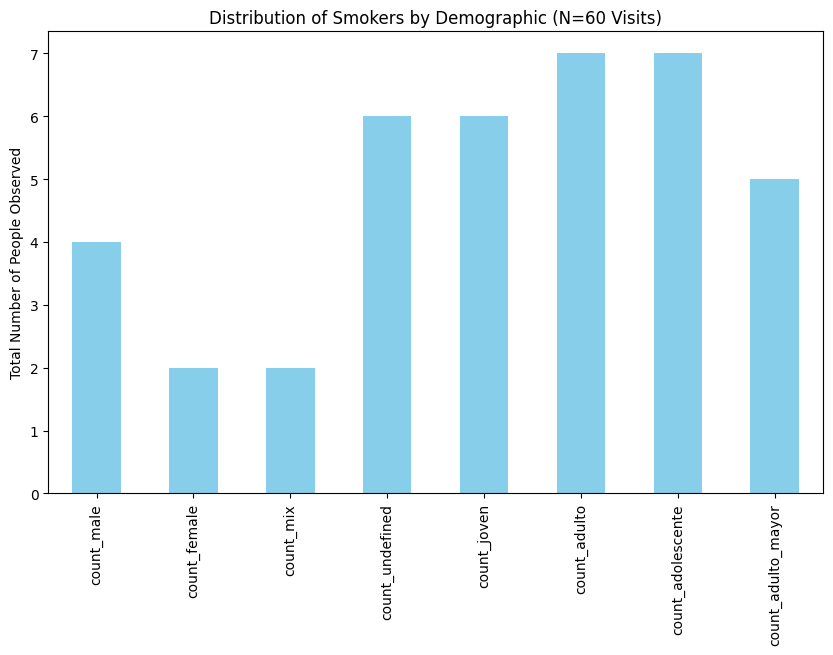

In [20]:
# descriptive statistics and frecuency distributions

df= pd.read_sql("""
SELECT 
    v.id AS visit_id,
    -- Sex Counts
    SUM(CASE WHEN r.question_id = 3 THEN r.numeric_value ELSE 0 END) AS count_male,
    SUM(CASE WHEN r.question_id = 4 THEN r.numeric_value ELSE 0 END) AS count_female,
    SUM(CASE WHEN r.question_id = 33 THEN r.numeric_value ELSE 0 END) AS count_mix,
    SUM(CASE WHEN r.question_id = 34 THEN r.numeric_value ELSE 0 END) AS count_undefined,
                
    -- Age Group Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS count_adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS count_joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS count_adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS count_adulto_mayor
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)

# 1. Totalize the observations across all 60 visits
totals = df[['count_male', 'count_female','count_mix','count_undefined', 'count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].sum()

# 2. Identify the Predominant Group
predominant_sex = totals[['count_male', 'count_female','count_mix','count_undefined']].idxmax()
predominant_age = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].idxmax()

print(f"PREDOMINANT PROFILE: {predominant_sex} and {predominant_age}")

# 3. Create a Composition Matrix (How Sex and Age overlap)
# This assumes you have mapped the individuals in your data processing
# If you don't have individual-level mapping, you use the aggregate sums:
sex_dist = totals[['count_male', 'count_female','count_mix','count_undefined']]
age_dist = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']]

# Visualization
plt.figure(figsize=(10, 6))
totals.plot(kind='bar', color='skyblue')
plt.title("Distribution of Smokers by Demographic (N=60 Visits)")
plt.ylabel("Total Number of People Observed")
plt.show()

### Q2: What is the predominant  sex and ethnic/racial group  of smokers observed on campus?

In [30]:
df= pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 5)
""", co)

Q2: What is the predominant sex and ethnic/racial group
    of smokers observed on campus?

── BIOLOGICAL SEX ──────────────────────────────────────────
Observed counts:
description
Hombre                         4
Mujer                          2
Expresión mixta/no definida    2
Indeterminada                  6

Total: 14
Predominant category: Indeterminada (n=6)

Chi-square Goodness of Fit:
  chi2    = 3.1429
  p-value = 0.3701
  Expected per category (if equal): 3.50
  ⚠️  Not significant: no sex predominates statistically (p ≥ 0.05)

Fisher's Exact Test (Hombre vs Mujer only):
  Hombre=4, Mujer=2
  Odds Ratio = 4.0000
  p-value    = 0.5671
  ⚠️  No significant difference between Hombre and Mujer.

── ETHNIC / RACIAL GROUP ───────────────────────────────────
Observed counts:
description
Mestizos           4
Indígena           6
Afrodecendiente    6

Total: 16
Predominant category: Indígena (n=6)

Chi-square Goodness of Fit:
  chi2    = 0.5000
  p-value = 0.7788
  Expected per catego

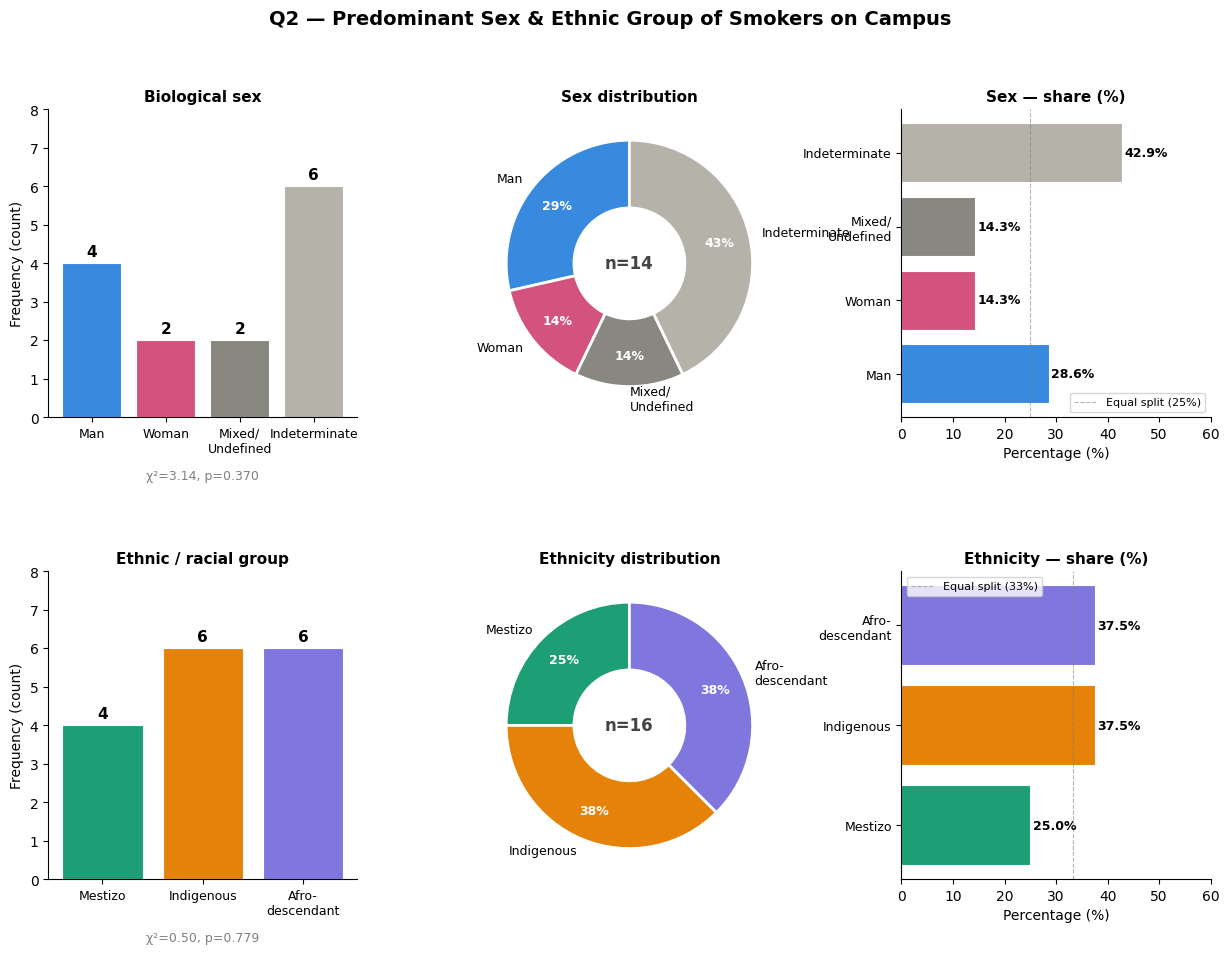

In [31]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')



sex_df = df[df['parent_question_id'] == 2].groupby('description')['numeric_value'].sum()
eth_df = df[df['parent_question_id'] == 5].groupby('description')['numeric_value'].sum()

# Logical order
sex_order = ['Hombre', 'Mujer', 'Expresión mixta/no definida', 'Indeterminada']
eth_order = ['Mestizos', 'Indígena', 'Afrodecendiente']
sex_df = sex_df.reindex(sex_order)
eth_df = eth_df.reindex(eth_order)

sex_labels_short = ['Man', 'Woman', 'Mixed/\nUndefined', 'Indeterminate']
eth_labels_short = ['Mestizo', 'Indigenous', 'Afro-\ndescendant']

# ── 2. Print results ──────────────────────────────────────────────────────────
print("=" * 62)
print("Q2: What is the predominant sex and ethnic/racial group")
print("    of smokers observed on campus?")
print("=" * 62)

# --- BIOLOGICAL SEX ---
print("\n── BIOLOGICAL SEX ──────────────────────────────────────────")
print(f"Observed counts:\n{sex_df.to_string()}")
print(f"\nTotal: {sex_df.sum()}")
print(f"Predominant category: {sex_df.idxmax()} (n={sex_df.max()})")

chi2_sex, p_sex = chisquare(sex_df.values)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2    = {chi2_sex:.4f}")
print(f"  p-value = {p_sex:.4f}")
exp_sex = sex_df.sum() / len(sex_df)
print(f"  Expected per category (if equal): {exp_sex:.2f}")
if p_sex < 0.05:
    print(f"  ✅ Significant: one sex category predominates (p < 0.05)")
else:
    print(f"  ⚠️  Not significant: no sex predominates statistically (p ≥ 0.05)")

# Fisher's exact — Hombre vs Mujer only
print(f"\nFisher's Exact Test (Hombre vs Mujer only):")
h_val = sex_df['Hombre']
m_val = sex_df['Mujer']
tot   = h_val + m_val
table_2x2 = [[h_val, m_val], [m_val, h_val]]
or_sex, p_fisher_sex = fisher_exact([[h_val, tot - h_val],
                                      [m_val, tot - m_val]])
print(f"  Hombre={h_val}, Mujer={m_val}")
print(f"  Odds Ratio = {or_sex:.4f}")
print(f"  p-value    = {p_fisher_sex:.4f}")
if p_fisher_sex < 0.05:
    print(f"  ✅ Significant difference between Hombre and Mujer.")
else:
    print(f"  ⚠️  No significant difference between Hombre and Mujer.")

# --- ETHNICITY ---
print(f"\n── ETHNIC / RACIAL GROUP ───────────────────────────────────")
print(f"Observed counts:\n{eth_df.to_string()}")
print(f"\nTotal: {eth_df.sum()}")
print(f"Predominant category: {eth_df.idxmax()} (n={eth_df.max()})")

chi2_eth, p_eth = chisquare(eth_df.values)
exp_eth = eth_df.sum() / len(eth_df)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2    = {chi2_eth:.4f}")
print(f"  p-value = {p_eth:.4f}")
print(f"  Expected per category (if equal): {exp_eth:.2f}")
if p_eth < 0.05:
    print(f"  ✅ Significant: one ethnic group predominates (p < 0.05)")
else:
    print(f"  ⚠️  Not significant: no ethnic group predominates statistically (p ≥ 0.05)")

# --- FINAL ANSWER ---
print(f"\n── FINAL ANSWER ────────────────────────────────────────────")
print(f"  Predominant biological sex  : {sex_df.idxmax()} (n={sex_df.max()}, "
      f"{sex_df.max()/sex_df.sum()*100:.1f}%)")
print(f"  Predominant ethnic group    : {eth_df.idxmax()} (n={eth_df.max()}, "
      f"{eth_df.max()/eth_df.sum()*100:.1f}%)")
print(f"\n  ⚠️  Sample size is very small (2 visits). Interpret with caution.")

# ── 3. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Q2 — Predominant Sex & Ethnic Group of Smokers on Campus",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

COLOR_SEX = ['#378ADD', '#D4537E', '#888780', '#B4B2A9']
COLOR_ETH = ['#1D9E75', '#E4820A', '#7F77DD']

# ── Plot 1: Sex bar chart
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(sex_df)), sex_df.values,
               color=COLOR_SEX, edgecolor='white', linewidth=0.8)
ax1.set_xticks(range(len(sex_df)))
ax1.set_xticklabels(sex_labels_short, fontsize=9)
ax1.set_ylabel('Frequency (count)', fontsize=10)
ax1.set_title('Biological sex', fontsize=11, fontweight='bold')
ax1.set_ylim(0, sex_df.max() + 2)
ax1.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, sex_df.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.text(0.5, -0.20, f"χ²={chi2_sex:.2f}, p={p_sex:.3f}",
         ha='center', transform=ax1.transAxes, fontsize=9, color='gray')

# ── Plot 2: Sex donut
ax2 = fig.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2.pie(
    sex_df.values, labels=sex_labels_short, colors=COLOR_SEX,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
centre = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre)
ax2.text(0, 0, f'n={sex_df.sum()}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')
ax2.set_title('Sex distribution', fontsize=11, fontweight='bold')

# ── Plot 3: Sex % horizontal bar
ax3 = fig.add_subplot(gs[0, 2])
pct_sex = (sex_df.values / sex_df.sum() * 100)
colors_sorted = [COLOR_SEX[i] for i in range(len(sex_df))]
hbars = ax3.barh(range(len(sex_df)), pct_sex,
                  color=COLOR_SEX, edgecolor='white', linewidth=0.8)
ax3.set_yticks(range(len(sex_df)))
ax3.set_yticklabels(sex_labels_short, fontsize=9)
ax3.set_xlabel('Percentage (%)', fontsize=10)
ax3.set_title('Sex — share (%)', fontsize=11, fontweight='bold')
ax3.set_xlim(0, 60)
ax3.spines[['top', 'right']].set_visible(False)
ax3.axvline(100/len(sex_df), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Equal split ({100/len(sex_df):.0f}%)')
ax3.legend(fontsize=8)
for bar, val in zip(hbars, pct_sex):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Plot 4: Ethnicity bar chart
ax4 = fig.add_subplot(gs[1, 0])
bars2 = ax4.bar(range(len(eth_df)), eth_df.values,
                color=COLOR_ETH, edgecolor='white', linewidth=0.8)
ax4.set_xticks(range(len(eth_df)))
ax4.set_xticklabels(eth_labels_short, fontsize=9)
ax4.set_ylabel('Frequency (count)', fontsize=10)
ax4.set_title('Ethnic / racial group', fontsize=11, fontweight='bold')
ax4.set_ylim(0, eth_df.max() + 2)
ax4.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars2, eth_df.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.text(0.5, -0.20, f"χ²={chi2_eth:.2f}, p={p_eth:.3f}",
         ha='center', transform=ax4.transAxes, fontsize=9, color='gray')

# ── Plot 5: Ethnicity donut
ax5 = fig.add_subplot(gs[1, 1])
wedges2, texts2, autotexts2 = ax5.pie(
    eth_df.values, labels=eth_labels_short, colors=COLOR_ETH,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts2:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
centre2 = plt.Circle((0, 0), 0.45, fc='white')
ax5.add_artist(centre2)
ax5.text(0, 0, f'n={eth_df.sum()}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')
ax5.set_title('Ethnicity distribution', fontsize=11, fontweight='bold')

# ── Plot 6: Ethnicity % horizontal bar
ax6 = fig.add_subplot(gs[1, 2])
pct_eth = (eth_df.values / eth_df.sum() * 100)
hbars2 = ax6.barh(range(len(eth_df)), pct_eth,
                   color=COLOR_ETH, edgecolor='white', linewidth=0.8)
ax6.set_yticks(range(len(eth_df)))
ax6.set_yticklabels(eth_labels_short, fontsize=9)
ax6.set_xlabel('Percentage (%)', fontsize=10)
ax6.set_title('Ethnicity — share (%)', fontsize=11, fontweight='bold')
ax6.set_xlim(0, 60)
ax6.spines[['top', 'right']].set_visible(False)
ax6.axvline(100/len(eth_df), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Equal split ({100/len(eth_df):.0f}%)')
ax6.legend(fontsize=8)
for bar, val in zip(hbars2, pct_eth):
    ax6.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.savefig('q2_sex_ethnicity.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q2_sex_ethnicity.png")

In [7]:
#chi square test

from scipy.stats import chi2_contingency

sex_vars = df_1[df_1['parent_question_id'] == 2]['description'].unique()
ethnic_vars = df_1[df_1['parent_question_id'] == 5]['description'].unique()

# 2. Pivot
pivot_df = df_1.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

sex_totals=pivot_df[sex_vars].sum()
ethnic_totals=pivot_df[ethnic_vars].sum()

observed = []

for sex in sex_vars:
    row = []
    for ethnic in ethnic_vars:
        
        val = (sex_totals[sex] * ethnic_totals[ethnic]) / sex_totals.sum()
        row.append(val)
    observed.append(row)

contingency_df = pd.DataFrame(observed, index=sex_vars, columns=ethnic_vars)


stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square Statistic: {stat:.2f}")
print(f"P-value: {p:.4f}")



Chi-Square Statistic: 0.00
P-value: 1.0000


### Q3: Are there specific demographics that are more likely to use electronic cigarettes/vapes (Question E.2) vs  traditional cigarettes (Question E.1) vs Marihuana?

Q3: Are certain demographics more likely to use each substance?
    Cigarette (E.1) | Vape (E.2) | Marihuana

Raw totals across all visits:
  Cigarette (E.1)     : 7
  Vape (E.2)          : 5
  Marihuana           : 7

Sex counts:
  Hombre                             : 4
  Mujer                              : 2
  Expresión mixta/no definida        : 2
  Indeterminada                      : 6

── CONTINGENCY TABLE (proportional distribution) ─────────────
                             Cigarette (E.1)  Vape (E.2)  Marihuana
Hombre                                  2.07        1.53       2.20
Mujer                                   0.96        0.64       0.87
Expresión mixta/no definida             0.96        0.64       0.87
Indeterminada                           3.02        2.18       3.07

── CHI-SQUARE TEST OF INDEPENDENCE (4 demographics × 3 products) ──
  chi2    = 0.1587
  p-value = 0.9999
  df      = 6

  Expected frequencies:
                             Cigarette (E.1)  Vape (E.2

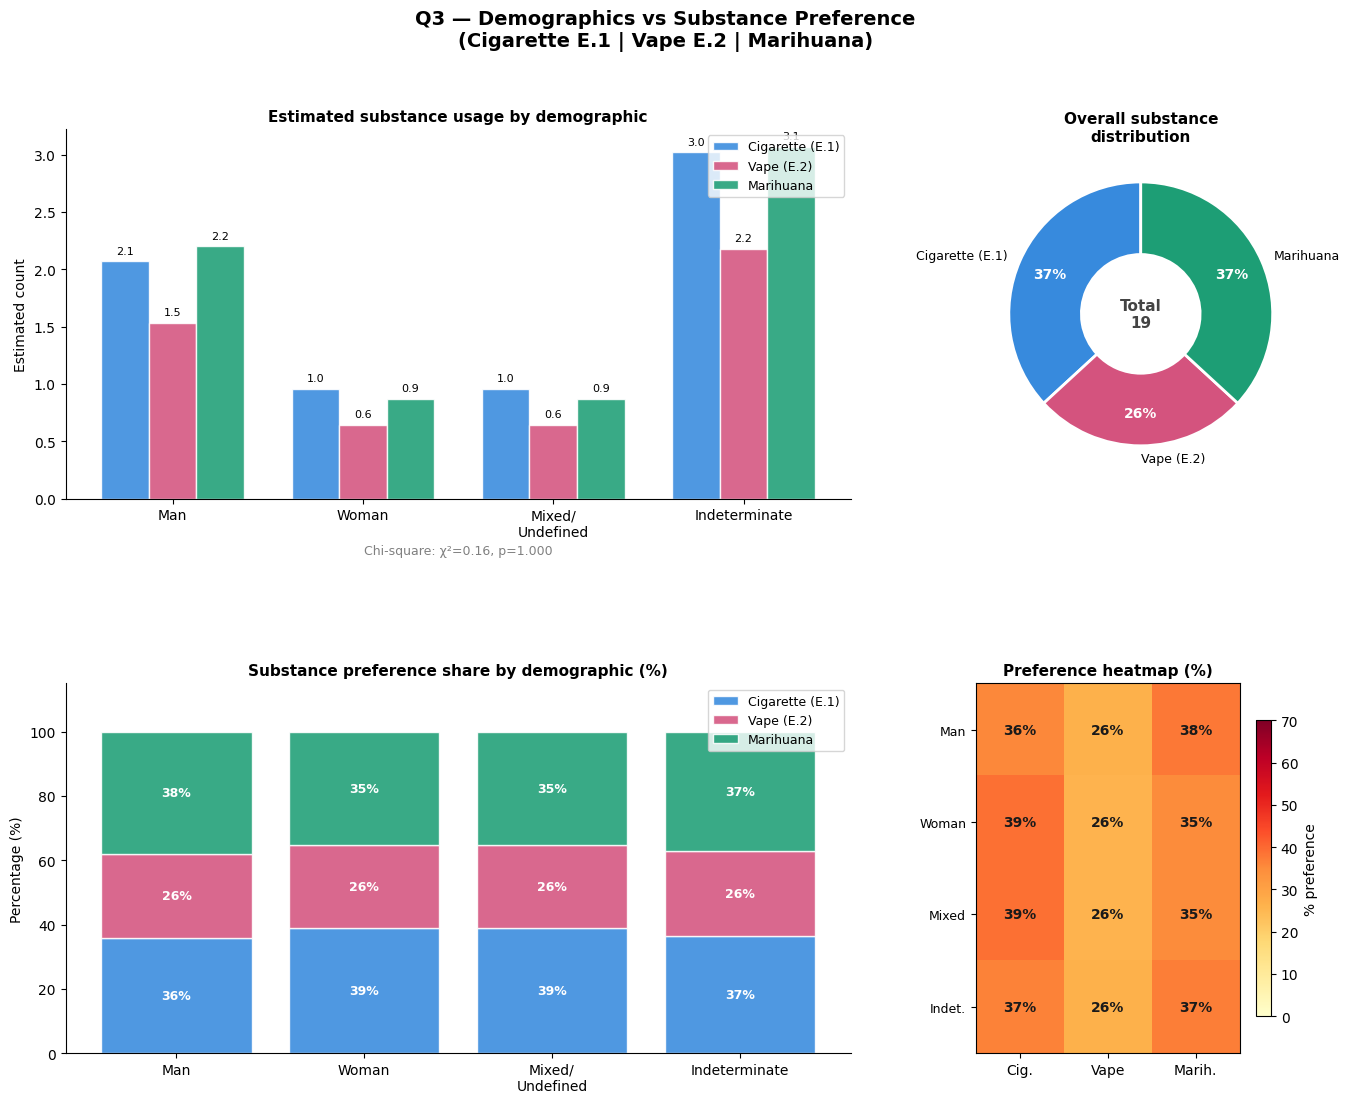

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

df= pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 14)
""", co)

# 2. Pivot
df = df_1.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)


CIG_COL = 'Cigarrillo (especificar en comentarios que tipo de cigarrillo es, ej: herbal o de otro tipo)'
VAP_COL = 'Vapeador'
MAR_COL = 'Marihuana'

sex_cols     = ['Hombre', 'Mujer', 'Expresión mixta/no definida', 'Indeterminada']
product_cols = [CIG_COL, VAP_COL, MAR_COL]
prod_labels  = ['Cigarette (E.1)', 'Vape (E.2)', 'Marihuana']
short_sex    = ['Man', 'Woman', 'Mixed/\nUndefined', 'Indeterminate']
short_sex_h  = ['Man', 'Woman', 'Mixed', 'Indet.']   # for heatmap

COLORS = {
    'Cigarette (E.1)': '#378ADD',
    'Vape (E.2)'     : '#D4537E',
    'Marihuana'      : '#1D9E75',
}

# ── 2. Build proportional contingency table (all 3 products) ──────────────────
contingency = {s: {p: 0.0 for p in prod_labels} for s in sex_cols}

for _, row in df.iterrows():
    sex_sum = sum(row[s] for s in sex_cols)
    if sex_sum == 0:
        continue
    for s in sex_cols:
        weight = row[s] / sex_sum
        contingency[s]['Cigarette (E.1)'] += weight * row[CIG_COL]
        contingency[s]['Vape (E.2)']      += weight * row[VAP_COL]
        contingency[s]['Marihuana']        += weight * row[MAR_COL]

ct     = pd.DataFrame(contingency).T.round(2)
ct_int = ct.round().astype(int)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Raw totals
raw_totals = {
    'Cigarette (E.1)': df[CIG_COL].sum(),
    'Vape (E.2)'     : df[VAP_COL].sum(),
    'Marihuana'      : df[MAR_COL].sum(),
}

# ── 3. Statistical tests ──────────────────────────────────────────────────────
print("=" * 65)
print("Q3: Are certain demographics more likely to use each substance?")
print("    Cigarette (E.1) | Vape (E.2) | Marihuana (E.3)")
print("=" * 65)

print(f"\nRaw totals across all visits:")
for k, v in raw_totals.items():
    print(f"  {k:20s}: {v}")

print(f"\nSex counts:")
for s in sex_cols:
    print(f"  {s:35s}: {df[s].sum()}")

print(f"\n── CONTINGENCY TABLE (proportional distribution) ─────────────")
print(ct.to_string())

# Chi-square on full 4x3 table
print(f"\n── CHI-SQUARE TEST OF INDEPENDENCE (4 demographics × 3 products) ──")
chi2, p_chi2, dof, expected = chi2_contingency(ct_int.values)
print(f"  chi2    = {chi2:.4f}")
print(f"  p-value = {p_chi2:.4f}")
print(f"  df      = {dof}")
exp_df = pd.DataFrame(expected.round(2), index=ct.index, columns=ct.columns)
print(f"\n  Expected frequencies:\n{exp_df.to_string()}")
low_exp = (expected < 5).any()
print(f"\n  {'⚠️  Some expected freq < 5 — interpret with caution' if low_exp else '✅ All expected freq ≥ 5'}")
if p_chi2 < 0.05:
    print(f"  ✅ Significant association (p < 0.05): demographics are")
    print(f"     associated with substance preference.")
else:
    print(f"  ⚠️  No significant association (p = {p_chi2:.3f} ≥ 0.05).")
    print(f"     Cannot confirm demographics drive substance preference.")

# Pairwise Fisher's exact — Hombre vs Mujer for each product pair
print(f"\n── FISHER'S EXACT TEST (Hombre vs Mujer, pairwise products) ──")
pairs = [
    ('Cigarette (E.1)', 'Vape (E.2)'),
    ('Cigarette (E.1)', 'Marihuana'),
    ('Vape (E.2)',      'Marihuana'),
]
for p1, p2 in pairs:
    row_h = [ct_int.loc['Hombre', p1], ct_int.loc['Hombre', p2]]
    row_m = [ct_int.loc['Mujer',  p1], ct_int.loc['Mujer',  p2]]
    table = [row_h, row_m]
    try:
        or_, pf = fisher_exact(table)
        sig = "✅ Significant" if pf < 0.05 else "⚠️  Not significant"
        print(f"  {p1} vs {p2}:")
        print(f"    Hombre={row_h}, Mujer={row_m} | OR={or_:.3f}, p={pf:.4f} → {sig}")
    except Exception as e:
        print(f"  {p1} vs {p2}: could not compute ({e})")

# Preference % per demographic
print(f"\n── SUBSTANCE PREFERENCE BY DEMOGRAPHIC (%) ───────────────────")
print(ct_pct.round(1).to_string())

print(f"\n── FINAL ANSWER ───────────────────────────────────────────────")
for prod in prod_labels:
    dom = ct[prod].idxmax()
    print(f"  Most {prod:20s} users: {dom} ({ct.loc[dom, prod]:.1f} est.)")
print(f"\n  ⚠️  Proportional estimation — only 2 visits. Low statistical power.")

# ── 4. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Q3 — Demographics vs Substance Preference\n(Cigarette E.1 | Vape E.2 | Marihuana)",
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)
x  = np.arange(len(sex_cols))
w  = 0.25

# ── Plot 1: Grouped bar chart — estimated counts
ax1 = fig.add_subplot(gs[0, :2])
offsets = [-w, 0, w]
for i, (prod, color) in enumerate(COLORS.items()):
    vals = ct[prod].values
    bars = ax1.bar(x + offsets[i], vals, w,
                   label=prod, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(short_sex, fontsize=10)
ax1.set_ylabel('Estimated count', fontsize=10)
ax1.set_title('Estimated substance usage by demographic', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.5, -0.15, f"Chi-square: χ²={chi2:.2f}, p={p_chi2:.3f}",
         ha='center', transform=ax1.transAxes, fontsize=9, color='gray')

# ── Plot 2: Overall totals donut chart
ax2 = fig.add_subplot(gs[0, 2])
donut_vals   = list(raw_totals.values())
donut_colors = list(COLORS.values())
wedges, texts, autotexts = ax2.pie(
    donut_vals, labels=prod_labels, colors=donut_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
centre = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre)
total_all = sum(donut_vals)
ax2.text(0, 0, f'Total\n{total_all}', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#444')
ax2.set_title('Overall substance\ndistribution', fontsize=11, fontweight='bold')

# ── Plot 3: Stacked % bar per demographic
ax3 = fig.add_subplot(gs[1, :2])
bottom = np.zeros(len(sex_cols))
for prod, color in COLORS.items():
    vals = ct_pct[prod].values
    bars = ax3.bar(x, vals, bottom=bottom, label=prod,
                   color=color, alpha=0.88, edgecolor='white')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 8:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bottom[i] + val/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += vals
ax3.set_xticks(x)
ax3.set_xticklabels(short_sex, fontsize=10)
ax3.set_ylabel('Percentage (%)', fontsize=10)
ax3.set_ylim(0, 115)
ax3.set_title('Substance preference share by demographic (%)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.spines[['top', 'right']].set_visible(False)

# ── Plot 4: Heatmap of % preference
ax4 = fig.add_subplot(gs[1, 2])
heatmap_data = ct_pct.values
im = ax4.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=70)
ax4.set_xticks(range(3))
ax4.set_xticklabels(['Cig.', 'Vape', 'Marih.'], fontsize=10)
ax4.set_yticks(range(len(sex_cols)))
ax4.set_yticklabels(short_sex_h, fontsize=9)
ax4.set_title('Preference heatmap (%)', fontsize=11, fontweight='bold')
for i in range(len(sex_cols)):
    for j in range(3):
        val = heatmap_data[i, j]
        color = 'white' if val > 40 else '#1a1a1a'
        ax4.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color)
plt.colorbar(im, ax=ax4, shrink=0.8, label='% preference')

plt.savefig('q3_all_substances.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q3_all_substances.png")





### Q4: Which Zones (from zone_zone) have the highest density of smokers per observation hour?

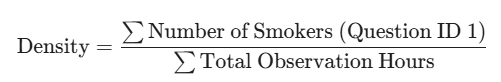

In [6]:
df=pd.read_sql("""
SELECT 
    z.id AS zone_id,           
    z.name AS zone_name,
    SUM(r.numeric_value) AS total_smokers,
    -- Calculate duration in hours
    SUM(TIMESTAMPDIFF(MINUTE, v.visit_start_date_time, v.visit_end_date_time) / 60.0) AS total_hours
FROM response_response r
JOIN visit_visit v ON r.visita_id = v.id
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
WHERE r.question_id = 1 -- Question: "Número de personas que se observaron fumando"
GROUP BY z.name,z.id
HAVING total_hours > 0;
""",co)

df['smoker_density'] = df['total_smokers'] / df['total_hours']

# 3. Sort by the highest density
df_ranked = df.sort_values(by='smoker_density', ascending=False)

# 4. Filter for Top 5 hotspots
top_hotspots = df_ranked.head(5)

print("### TOP SMOKING HOTSPOTS (Density per Hour) ###")
print(top_hotspots[['zone_name', 'smoker_density']])

### TOP SMOKING HOTSPOTS (Density per Hour) ###
                                           zone_name  smoker_density
1            Central, pasillos de central y banderas            40.0
0  Plazoleta de ingenierías, pasillos de la Escue...             0.0


In [7]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. The ANOVA test
# We group the smokers_per_hour by zone_name
zones = [group['total_smokers'].values for name, group in df.groupby('zone_name')]
f_stat, p_val = f_oneway(*zones)

print(f"ANOVA P-value: {p_val:.4f}")

# 2. If P < 0.05, we find the 'Winner' using Tukey HSD
if p_val < 0.05:
    print("Significant difference found! Performing Post-Hoc analysis...")
    tukey = pairwise_tukeyhsd(endog=df['smokers_per_hour'], 
                              groups=df['zone_name'], 
                              alpha=0.05)
    print(tukey)



ANOVA P-value: nan


c:\Users\andres\Desktop\SEPTIMO SEMESTRE\MONITORIA\analisis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\andres\AppData\Local\Temp\ipykernel_26120\4195905571.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*zones)


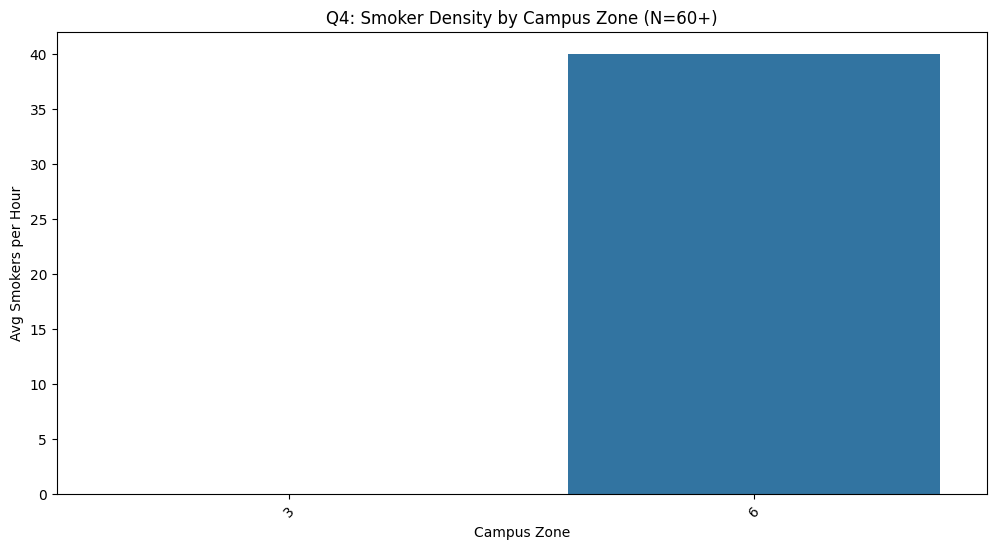

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x='zone_id', y='smoker_density', data=df, capsize=.2)
plt.title("Q4: Smoker Density by Campus Zone (N=60+)")
plt.ylabel("Avg Smokers per Hour")
plt.xlabel("Campus Zone")
plt.xticks(rotation=45)
plt.show()

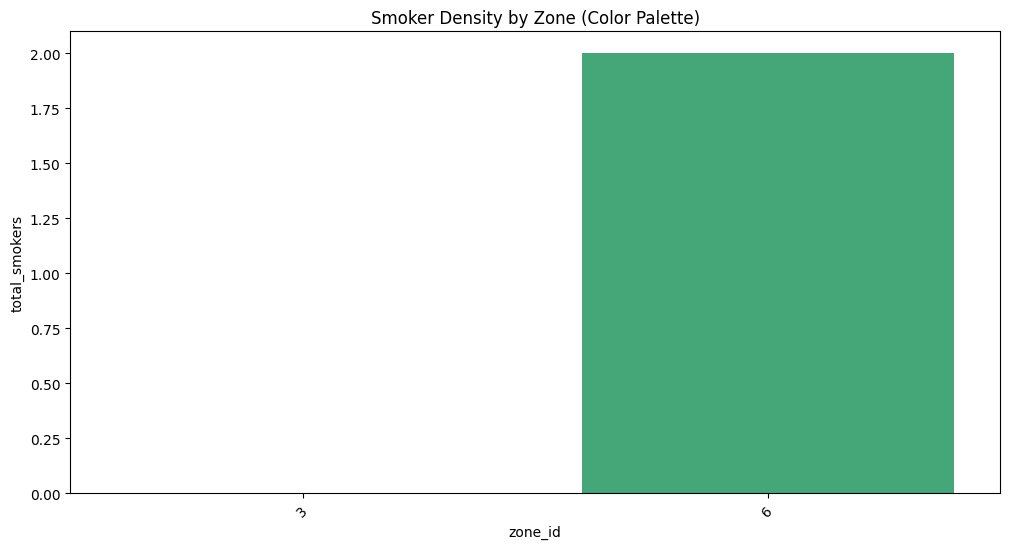

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

# 'hue' is the secret—by setting hue to the same variable as x, 
# Seaborn gives every bar a unique color from the palette.
sns.barplot(
    x='zone_id', 
    y='total_smokers', 
    data=df, 
    palette='viridis', 
    hue='zone_name', 
    legend=False
)

plt.title("Smoker Density by Zone (Color Palette)")
plt.xticks(rotation=45)
plt.show()

### Q5: How often do vulnerable populations (Children and Pregnant Women - Questions T & U) coincide in the same zones as active smokers?

In [15]:
df=pd.read_sql("""
SELECT 
    v.id AS visita_id,
    z.name AS zone_name,
    r1.numeric_value AS smoker_count,
    r2.numeric_value AS pregnant_count,
    r3.numeric_value AS children_count
FROM visit_visit v
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
JOIN response_response r1 ON r1.visita_id = v.id AND r1.question_id = 1
LEFT JOIN response_response r2 ON r2.visita_id = v.id AND r2.question_id = 97
LEFT JOIN response_response r3 ON r3.visita_id = v.id AND r3.question_id = 98;
""",co)

df

,visita_id,zone_name,smoker_count,pregnant_count,children_count
0,122,"Plazoleta de ingenierías, pasillos de la Escue...",0,4,5
1,123,"Central, pasillos de central y banderas",2,3,3


In [17]:
# 1. Identify "Coincidence Visits" (Both smokers and vulnerable people present)
df['coincidence'] = (df['smoker_count'] > 0) & ((df['pregnant_count'] > 0) | (df['children_count'] > 0))

# 2. Calculate the Percentage of Risk
total_visits = len(df)
risk_visits = df['coincidence'].sum()
risk_percentage = (risk_visits / total_visits) * 100

print(f"Risk Assessment: Vulnerable populations coincided with smokers in {risk_percentage}% of observed sessions.")

Risk Assessment: Vulnerable populations coincided with smokers in 50.0% of observed sessions.


### Q6: Is there a relationship between the number of smokers and the number of complaints/rejections (Question M) from non-smokers?
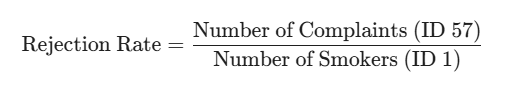

In [ ]:
df=pd.read_sql("""
SELECT v.id as visit_id, r1.numeric_value as smoker_count, r2.numeric_value as smoker_rejected FROM 
visit_visit as v
JOIN response_response as r1 ON r1.visita_id=v.id AND r1.question_id=1
LEFT JOIN response_response as r2 ON r2.visita_id=v.id AND r2.question_id=57            
""",co)


df['smoker_rejected'] = df['smoker_rejected'].fillna(0)

correlation = df['smoker_count'].corr(df['smoker_rejected'], method='spearman')

# 3. Calculate Ratio
df['ratio'] = df['smoker_rejected'] / df['smoker_count']

print(df)

print(f"Average Rejection Ratio: {df['ratio'].mean()} complaints per smoker.")

print(f'correlation: {correlation}')

   visit_id  smoker_count  smoker_rejected  ratio
0       122             0                2    inf
1       123             2                5    2.5
Average Rejection Ratio: inf complaints per smoker.
correlation: 0.9999999999999999


### Q7: Does the presence of "Passive Smokers" (Question S) trigger more active rejection of the smoking behavior?

Q7: Does the presence of Passive Smokers trigger more
    active rejection of smoking behavior?

Data per visit:
           passive_smokers  active_rejection
visita_id                                   
122                      2                 2
123                      4                 4

Variable types:
  passive_smokers   → Discrete count (ratio scale)
  active_rejection  → Discrete count (ratio scale)

── SPEARMAN CORRELATION ────────────────────────────────────
  (Non-parametric — correct for count data, small N)
  ρ (rho)  = 1.0000
  p-value  = nan
  Interpretation: very strong positive correlation
  ⚠️  Not significant (p = nan)
     Cannot confirm the association statistically.

── PEARSON CORRELATION (for reference) ─────────────────────
  (Parametric — less reliable with only 2 data points)
  r        = 1.0000
  p-value  = 1.0000

── SIMPLE LINEAR REGRESSION ────────────────────────────────
  Predicting active_rejection from passive_smokers
  Slope (β)   = 1.0000
  Interce

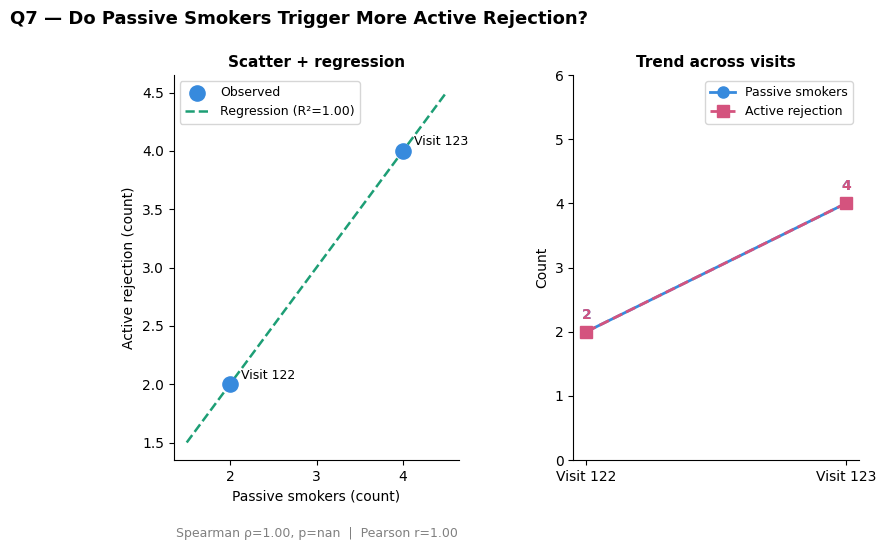

In [36]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr, linregress
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & reshape data ────────────────────────────────────────────────────
df = pd.read_csv('q7_question.csv')

# Clean description names
df['description'] = df['description'].str.replace(r'\r\n|\xa0', ' ', regex=True).str.strip()

PASSIVE_KEY   = df['description'].unique()[0]   # count of non-smokers nearby
REJECTION_KEY = df['description'].unique()[1]   # count who rejected/complained

passive   = df[df['description'] == PASSIVE_KEY].set_index('visita_id')['numeric_value']
rejection = df[df['description'] == REJECTION_KEY].set_index('visita_id')['numeric_value']

# Align by visit
combined = pd.DataFrame({
    'passive_smokers' : passive,
    'active_rejection': rejection
}).sort_index()

print("=" * 62)
print("Q7: Does the presence of Passive Smokers trigger more")
print("    active rejection of smoking behavior?")
print("=" * 62)

print(f"\nData per visit:")
print(combined.to_string())
print(f"\nVariable types:")
print(f"  passive_smokers   → Discrete count (ratio scale)")
print(f"  active_rejection  → Discrete count (ratio scale)")

x = combined['passive_smokers'].values
y = combined['active_rejection'].values

# ── 2. Spearman correlation ───────────────────────────────────────────────────
print(f"\n── SPEARMAN CORRELATION ────────────────────────────────────")
print(f"  (Non-parametric — correct for count data, small N)")
rho, p_spear = spearmanr(x, y)
print(f"  ρ (rho)  = {rho:.4f}")
print(f"  p-value  = {p_spear:.4f}")
if abs(rho) >= 0.9:
    strength = "very strong"
elif abs(rho) >= 0.7:
    strength = "strong"
elif abs(rho) >= 0.5:
    strength = "moderate"
else:
    strength = "weak"
direction = "positive" if rho > 0 else "negative"
print(f"  Interpretation: {strength} {direction} correlation")
if p_spear < 0.05:
    print(f"  ✅ Significant (p < 0.05): passive smokers ARE associated")
    print(f"     with more active rejection.")
else:
    print(f"  ⚠️  Not significant (p = {p_spear:.3f})")
    print(f"     Cannot confirm the association statistically.")

# ── 3. Pearson correlation (for reference) ────────────────────────────────────
print(f"\n── PEARSON CORRELATION (for reference) ─────────────────────")
print(f"  (Parametric — less reliable with only 2 data points)")
r_pear, p_pear = pearsonr(x, y)
print(f"  r        = {r_pear:.4f}")
print(f"  p-value  = {p_pear:.4f}")

# ── 4. Simple linear regression ──────────────────────────────────────────────
print(f"\n── SIMPLE LINEAR REGRESSION ────────────────────────────────")
print(f"  Predicting active_rejection from passive_smokers")
slope, intercept, r_val, p_reg, se = linregress(x, y)
print(f"  Slope (β)   = {slope:.4f}")
print(f"  Intercept   = {intercept:.4f}")
print(f"  R²          = {r_val**2:.4f}")
print(f"  p-value     = {p_reg:.4f}")
print(f"  Equation    : rejection = {slope:.2f} × passive_smokers + {intercept:.2f}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print(f"\n── FINAL ANSWER ────────────────────────────────────────────")
print(f"  Passive smokers per visit   : {x.tolist()}")
print(f"  Active rejection per visit  : {y.tolist()}")
print(f"  Spearman ρ = {rho:.2f} ({strength} {direction} correlation)")
if p_spear < 0.05:
    print(f"  ✅ Yes — more passive smokers → more active rejection")
else:
    print(f"  ⚠️  Cannot confirm with only {len(x)} visits (very low statistical power)")
    print(f"     The trend is {direction} (ρ={rho:.2f}) but more data is needed.")

# ── 6. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
fig.suptitle("Q7 — Do Passive Smokers Trigger More Active Rejection?",
             fontsize=13, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

COLOR_PASSIVE   = '#378ADD'
COLOR_REJECTION = '#D4537E'
COLOR_REG       = '#1D9E75'

visits = combined.index.astype(str).tolist()
visit_labels = [f'Visit {v}' for v in visits]


# ── Plot 2: Scatter + regression line
ax2 = fig.add_subplot(gs[1])
ax2.scatter(x, y, color=COLOR_PASSIVE, s=120, zorder=5, label='Observed')
for i, v in enumerate(visits):
    ax2.annotate(f'Visit {v}', (x[i], y[i]),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)
x_line = np.linspace(min(x)-0.5, max(x)+0.5, 100)
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line, color=COLOR_REG, linewidth=1.8,
         linestyle='--', label=f'Regression (R²={r_val**2:.2f})')
ax2.set_xlabel('Passive smokers (count)', fontsize=10)
ax2.set_ylabel('Active rejection (count)', fontsize=10)
ax2.set_title('Scatter + regression', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.text(0.5, -0.20,
         f"Spearman ρ={rho:.2f}, p={p_spear:.3f}  |  Pearson r={r_pear:.2f}",
         ha='center', transform=ax2.transAxes, fontsize=9, color='gray')

# ── Plot 3: Trend line per variable across visits
ax3 = fig.add_subplot(gs[2])
ax3.plot(visit_labels, x, 'o-', color=COLOR_PASSIVE,
         linewidth=2, markersize=8, label='Passive smokers')
ax3.plot(visit_labels, y, 's--', color=COLOR_REJECTION,
         linewidth=2, markersize=8, label='Active rejection')
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Trend across visits', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)
ax3.set_ylim(0, max(max(x), max(y)) + 2)
for i, (xv, yv) in enumerate(zip(x, y)):
    ax3.text(i, xv + 0.2, str(xv), ha='center', fontsize=10,
             fontweight='bold', color=COLOR_PASSIVE)
    ax3.text(i, yv + 0.2, str(yv), ha='center', fontsize=10,
             fontweight='bold', color=COLOR_REJECTION)

plt.tight_layout()
plt.savefig('q7_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q7_analysis.png")

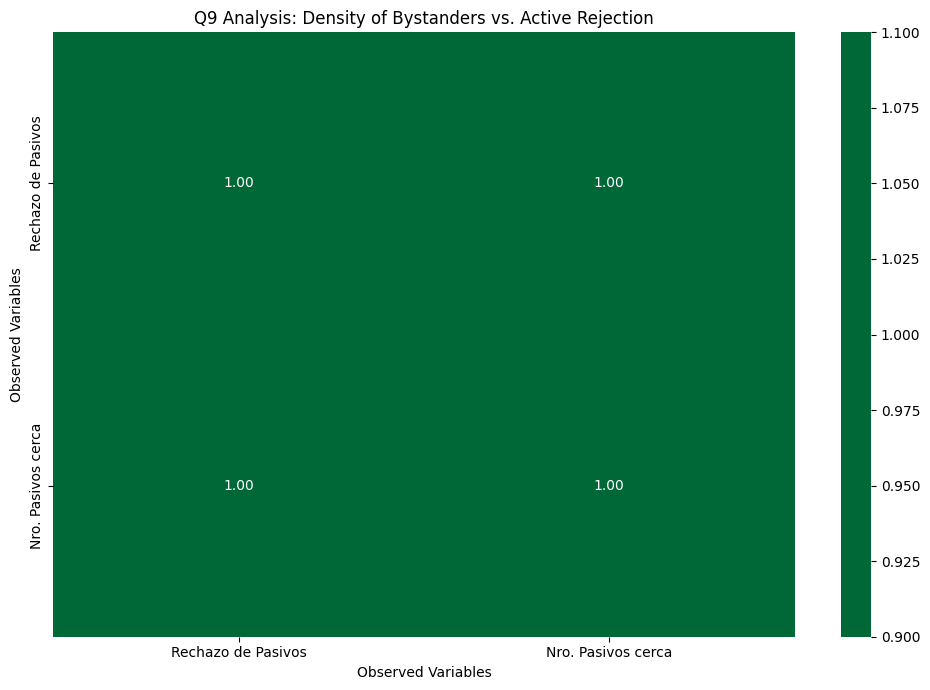

In [32]:
# 1. SQL remains good
df = pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id 
WHERE q.id IN (78, 79)
""", co)

# 2. Pivot
pivot_df = df.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# Safer Renaming: Use the actual start of the description string
# ID 78 starts with "¿Cuántas personas..."
# ID 79 starts with "¿Ante el acto..."
mapping = {}
for col in pivot_df.columns:
    if "radio" in col:
        mapping[col] = "Nro. Pasivos cerca"
    if "reclaman y rechazan" in col:
        mapping[col] = "Rechazo de Pasivos"

pivot_df = pivot_df.rename(columns=mapping)

# 3. Correlation
corr_matrix = pivot_df.corr(method='spearman')

# 4. Visualization
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', # Red to Green shows the 'tension' well
            center=0)

plt.title("Q9 Analysis: Density of Bystanders vs. Active Rejection")
plt.ylabel("Observed Variables")
plt.xlabel("Observed Variables")
plt.tight_layout()
plt.show()





([<matplotlib.axis.XTick at 0x1f7cc387ed0>,
 [Text(0, 0, 'No Passive Smokers'), Text(1, 0, 'Passive Smokers Present')])

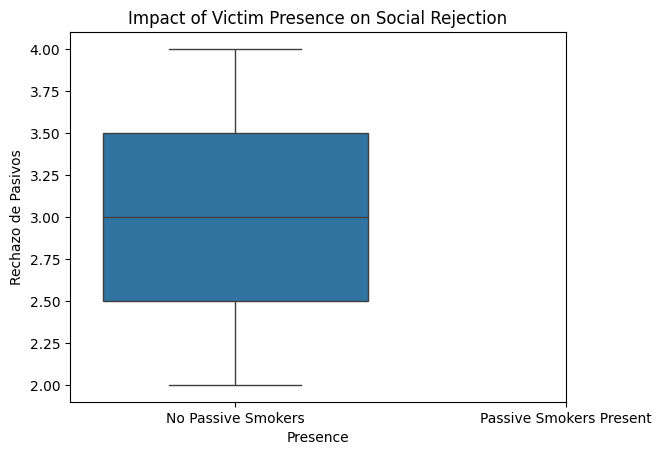

In [25]:
# Create the 'Has Passive Smokers' group
pivot_df['Presence'] = pivot_df['Nro. Pasivos cerca'] > 0

# Visual comparison
sns.boxplot(x='Presence', y='Rechazo de Pasivos', data=pivot_df)
plt.title("Impact of Victim Presence on Social Rejection")
plt.xticks([0, 1], ['No Passive Smokers', 'Passive Smokers Present'])

C:\Users\andres\AppData\Local\Temp\ipykernel_17372\180307394.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = ttest_ind(group_with_passive, group_no_passive, equal_var=False)
C:\Users\andres\AppData\Local\Temp\ipykernel_17372\180307394.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_passive', y='Rechazo de Pasivos', data=pivot_df, palette="Set2")


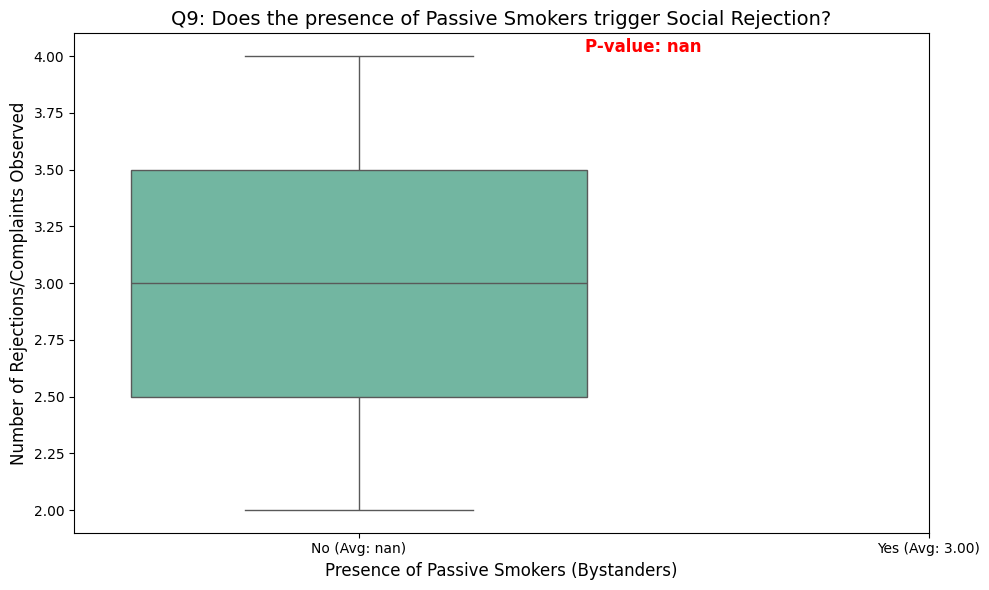

CONCLUSION: No significant difference was found (p=nan).


In [27]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the classification: Presence vs. Absence
# 'Nro. Pasivos cerca' (ID 78) is our 'switch'
pivot_df['has_passive'] = pivot_df['Nro. Pasivos cerca'] > 0

# 2. Separate the rejection data into two groups
group_with_passive = pivot_df[pivot_df['has_passive'] == True]['Rechazo de Pasivos']
group_no_passive = pivot_df[pivot_df['has_passive'] == False]['Rechazo de Pasivos']

# 3. Statistical T-Test (Is the difference real or luck?)
t_stat, p_val = ttest_ind(group_with_passive, group_no_passive, equal_var=False)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_passive', y='Rechazo de Pasivos', data=pivot_df, palette="Set2")

# Formatting the plot
plt.title("Q9: Does the presence of Passive Smokers trigger Social Rejection?", fontsize=14)
plt.xlabel("Presence of Passive Smokers (Bystanders)", fontsize=12)
plt.ylabel("Number of Rejections/Complaints Observed", fontsize=12)
plt.xticks([0, 1], [f'No (Avg: {group_no_passive.mean():.2f})', 
                    f'Yes (Avg: {group_with_passive.mean():.2f})'])

# Add P-value note to the plot
plt.text(0.5, pivot_df['Rechazo de Pasivos'].max(), f"P-value: {p_val:.4f}", 
         ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# 5. Print Conclusion
if p_val < 0.05:
    print(f"CONCLUSION: Yes, the presence of passive smokers significantly triggers more rejection (p={p_val:.4f}).")
else:
    print(f"CONCLUSION: No significant difference was found (p={p_val:.4f}).")

## Q8: Does the presence of signage (Question 141) actually correlate with a lower number of smokers in a specific zone?

In [39]:
from scipy.stats import spearmanr

df_signs = pd.read_sql("""
SELECT 
    v.id AS visita_id,
    SUM(CASE WHEN r.question_id = 141 THEN r.numeric_value ELSE 0 END) AS total_avisos,
    SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END) AS total_fumadores
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id
""", co)

# 2. Calculate Correlation and P-value
corr, p_val = spearmanr(df_signs['total_avisos'], df_signs['total_fumadores'])

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_val:.4f}")

Spearman Correlation: -1.000
P-value: nan


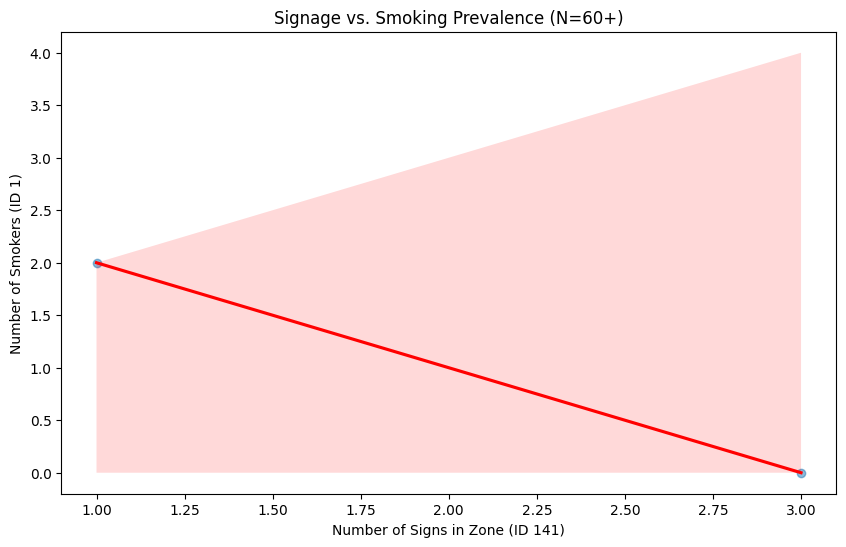

In [40]:
plt.figure(figsize=(10, 6))
sns.regplot(x='total_avisos', y='total_fumadores', data=df_signs, 
            line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})

plt.title("Signage vs. Smoking Prevalence (N=60+)")
plt.xlabel("Number of Signs in Zone (ID 141)")
plt.ylabel("Number of Smokers (ID 1)")
plt.show()

## Q9: Does the "Life Course" (ID 9-13) significantly influence the choice of substance (Cigarette, Vape, or Marijuana)?

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

df= pd.read_sql("""
SELECT 
    v.id AS visita_id,
    -- Life Course Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS Adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS Joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS Adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS Adulto_Mayor,
    -- Substance Counts
    SUM(CASE WHEN r.question_id = 15 THEN r.numeric_value ELSE 0 END) AS Cigarrillo,
    SUM(CASE WHEN r.question_id = 16 THEN r.numeric_value ELSE 0 END) AS Vapeador,
    SUM(CASE WHEN r.question_id = 35 THEN r.numeric_value ELSE 0 END) AS Marihuana
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)



# 1. Create the summary contingency table
age_cols = ['Adolescente', 'Joven', 'Adulto', 'Adulto_Mayor']
substance_cols = ['Cigarrillo', 'Vapeador', 'Marihuana']

# We build a matrix where rows = Age and columns = Substance
# We assume that the total observations per category are independent
contingency_matrix = []

for age in age_cols:
    row = []
    # Total people of this age group across all visits
    total_age = df[age].sum()
    for sub in substance_cols:
        
        total_sub = df[sub].sum()
        row.append(total_sub * (total_age / df[age_cols].sum().sum()))
    contingency_matrix.append(row)

contingency_df = pd.DataFrame(contingency_matrix, index=age_cols, columns=substance_cols)

# 2. Run Chi-Square
stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square P-value: {p:.4f}")




Chi-Square P-value: 1.0000


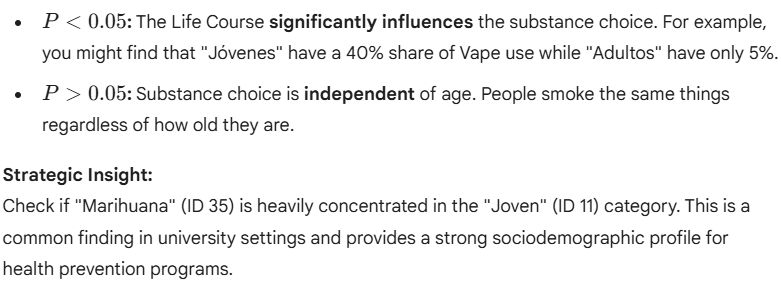

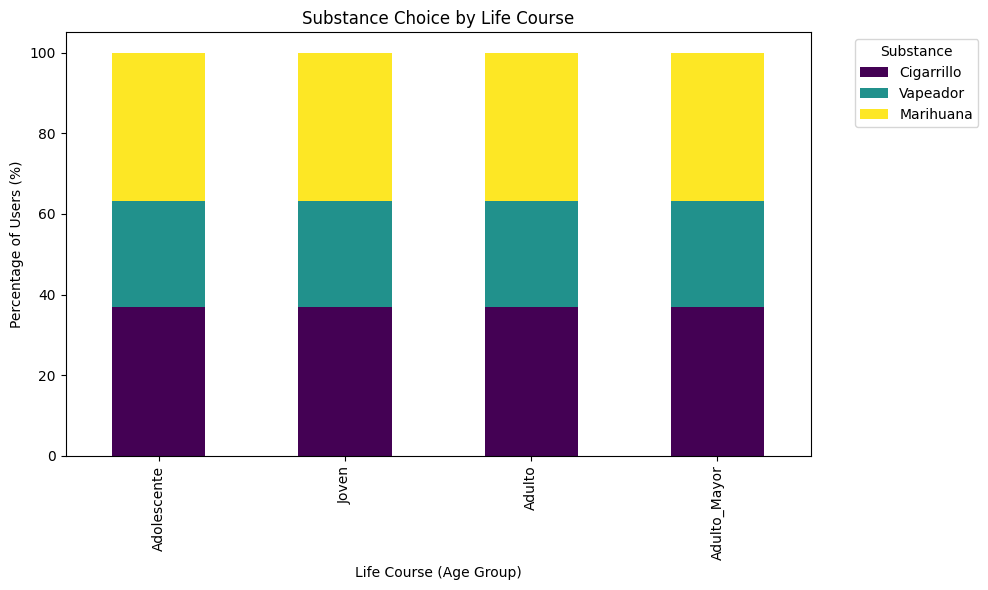

In [6]:
# Normalize the data to show percentages per age group
df_percent = contingency_df.div(contingency_df.sum(axis=1), axis=0) * 100

df_percent.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Substance Choice by Life Course")
plt.ylabel("Percentage of Users (%)")
plt.xlabel("Life Course (Age Group)")
plt.legend(title="Substance", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Q10: How does the method of acquisition (Bought on-site vs. Brought from home) vary by substance?

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df=pd.read_sql("""
SELECT 
    -- Totals for Cigarettes
    SUM(CASE WHEN r.question_id = 18 THEN r.numeric_value ELSE 0 END) AS cig_home,
    SUM(CASE WHEN r.question_id = 21 THEN r.numeric_value ELSE 0 END) AS cig_bought,
    SUM(CASE WHEN r.question_id = 36 THEN r.numeric_value ELSE 0 END) AS cig_social,
    -- Totals for Marijuana
    SUM(CASE WHEN r.question_id = 23 THEN r.numeric_value ELSE 0 END) AS mj_home,
    SUM(CASE WHEN r.question_id = 26 THEN r.numeric_value ELSE 0 END) AS mj_bought,
    SUM(CASE WHEN r.question_id = 25 THEN r.numeric_value ELSE 0 END) AS mj_social,
    -- Totals for Vape
    SUM(CASE WHEN r.question_id = 28 THEN r.numeric_value ELSE 0 END) AS vape_home,
    SUM(CASE WHEN r.question_id = 31 THEN r.numeric_value ELSE 0 END) AS vape_bought,
    SUM(CASE WHEN r.question_id = 30 THEN r.numeric_value ELSE 0 END) AS vape_social
FROM response_response r;
""",co)




# Data from the SQL query
data = {
    'Brought from Home': df[['cig_home', 'mj_home', 'vape_home']].values.flat,
    'Bought on Campus': df[['cig_bought', 'mj_bought', 'vape_bought']].values.flat,
    'Socially Offered': df[['cig_social', 'mj_social', 'vape_social']].values.flat
}

# Creating the DataFrame (Substances as Rows)
df_market = pd.DataFrame(data, index=['Cigarette', 'Marijuana', 'Vape'])

# Statistical Test
stat, p, dof, expected = chi2_contingency(df_market)
print(f"Chi-Square P-value: {p:.4f}")



Chi-Square P-value: 0.9860


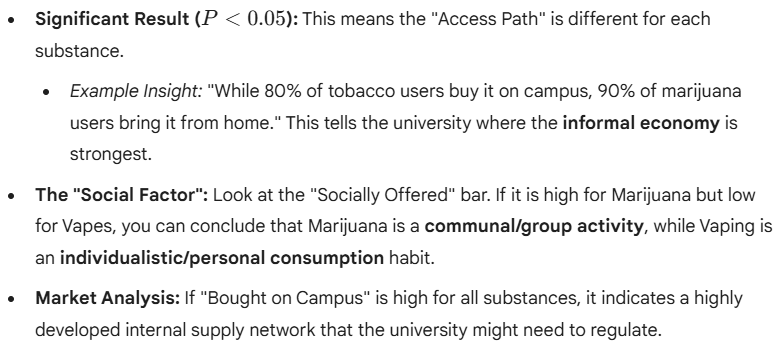

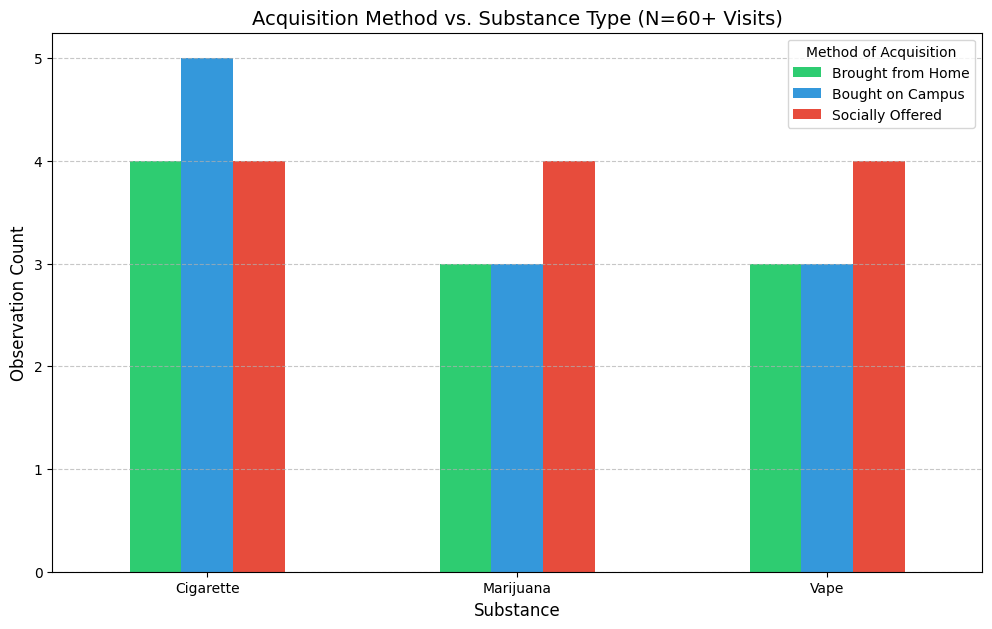

In [17]:
# Plotting
df_market.plot(kind='bar', figsize=(12, 7), color=['#2ecc71', '#3498db', '#e74c3c'])

plt.title("Acquisition Method vs. Substance Type (N=60+ Visits)", fontsize=14)
plt.ylabel("Observation Count", fontsize=12)
plt.xlabel("Substance", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Method of Acquisition")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Q11: What percentage of smoking events are social (ID 56: "Talking to others") versus solitary (ID 53-55: using laptops/phones), and does this vary by Zone?